# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

**Refresh/Content Scoring (Lane-2)**, because we have to check whether there are pages that should be reviewed and scored based on their refresh opportunity, protection, monitoring, or expansion opportunities respectively.  

**Default dataset**: Starter playground plus warehouse support.

**Output**: Ranked review queue with scores, actions, and reason codes.

In [16]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


Again running the models to prove that trained models work better in this case than simple rule-based system.

In [17]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py


▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queu

In [18]:
import json
res = json.load(open("outputs/model_results.json"))

# Using Precision@50 as Precision@10 is not available in model_results.json
base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


## 2. Target or proxy

The target for this ML task is to predict whether a piece of content has a **'refresh opportunity'**. This can be framed as a binary classification problem, where the model outputs a score indicating the likelihood of a refresh being needed, which is then thresholded to define the label.

This label is generated from a **defined rule** based on specific criteria within the `scripts/run_all.py` pipeline (specifically, in the 'Prepare features' step where the label is defined). It's not directly an 'observed outcome' in the raw dataset but rather a constructed label based on business logic.

***I] 1 (True): Indicates that the content does have a 'refresh opportunity'. This is the positive class that the model is trying to identify.***

***II] 0 (False): Indicates that the content does not have a 'refresh opportunity'.***


In [19]:
import pandas as pd

# Load the feature vector which contains the defined label
feature_vector_path = "data/processed/refresh_feature_vector.csv"
df_features = pd.read_csv(feature_vector_path)

# Print all columns to verify the exact name of the target column
print("All columns in the DataFrame:", df_features.columns.tolist())

# Display the value counts of the 'measurable_opportunity' column to understand its distribution
print("\nDistribution of the target label (measurable_opportunity):")
display(df_features['measurable_opportunity'].value_counts())

print("\nFirst few rows of the feature vector with the label:")
display(df_features.head())

All columns in the DataFrame: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'is_declining_label', 'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_sessions_90d', 'has_clicks', 'has_ai_sessions', 'measurable_opportunity']

Distribution of the target label 

,count
measurable_opportunity,
1,22006
0,7994



First few rows of the feature vector with the label:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,trend_direction,trend_pct,is_declining_label,log_impressions_90d,log_clicks_90d,log_sessions_90d,log_ai_sessions_90d,has_clicks,has_ai_sessions,measurable_opportunity
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,down,-41.4,1,8.243808,3.401197,2.890372,0.0,1,0,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,down,-57.7,1,9.636980,2.079442,2.302585,0.0,1,0,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,down,-60.9,1,9.440023,2.484907,2.484907,0.0,1,0,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,0.0,0.0,...,stable,-13.8,0,9.371779,4.077537,4.369448,0.0,1,0,1
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,down,-34.7,1,9.859588,3.218876,4.983607,0.0,1,0,1


## 3. Success metric

For this ML task, a strong success metric is **Precision@50**.

**Precision@50** measures the proportion of actual 'refresh opportunity' pages among the top 50 pages that the model predicts as having the highest refresh potential. Since the goal is to prioritize a ranked review queue for content refreshes, this metric directly reflects the efficiency of our recommendations.

**What number means 'good'?**
A 'good' model would achieve a Precision@50 significantly higher than the current baseline. Given the random forest model's current performance, a Precision@50 of **0.70 or higher** would indicate a highly effective system that reliably identifies valuable refresh opportunities. This represents a substantial improvement over the hand-written rule.

***A good ML model should demonstrate a substantial improvement over simple rule. Here, we see 0.74 precision@50 is more than double te baseline, indicating that the random forest model is far more effective at identifying true refresh opportunities among the top 50 pages.***

In [20]:
import json

# Load model results to check Precision@50
res = json.load(open("outputs/model_results.json"))

current_rf_precision = res["models"]["random_forest"]["precision_at_50"]
print(f"Current Random Forest Precision@50: {current_rf_precision:.3f}")

Current Random Forest Precision@50: 0.740


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

The **'unit of analysis'** refers a single piece of content, as represented by each row in your df_features DataFrame. Each row contains all the features and the target label (measurable_opportunity) for a unique content item.

In [21]:
# Load the feature vector which contains the defined label
# feature_vector_path = "data/processed/refresh_feature_vector.csv"
# df_features = pd.read_csv(feature_vector_path)

print(f"The DataFrame `df_features` has {df_features.shape[0]} rows and {df_features.shape[1]} columns.")
print("Each row represents a unique piece of content, which is the unit of analysis for this ML task.")

print("\nFirst 5 rows of the DataFrame, where each row is a unit of analysis:")
display(df_features.head())

The DataFrame `df_features` has 30000 rows and 52 columns.
Each row represents a unique piece of content, which is the unit of analysis for this ML task.

First 5 rows of the DataFrame, where each row is a unit of analysis:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,trend_direction,trend_pct,is_declining_label,log_impressions_90d,log_clicks_90d,log_sessions_90d,log_ai_sessions_90d,has_clicks,has_ai_sessions,measurable_opportunity
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,down,-41.4,1,8.243808,3.401197,2.890372,0.0,1,0,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,down,-57.7,1,9.636980,2.079442,2.302585,0.0,1,0,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,down,-60.9,1,9.440023,2.484907,2.484907,0.0,1,0,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,0.0,0.0,...,stable,-13.8,0,9.371779,4.077537,4.369448,0.0,1,0,1
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,down,-34.7,1,9.859588,3.218876,4.983607,0.0,1,0,1


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

Machine learning models, particularly algorithms like Random Forest, excel where fixed rules fail due to several factors:

*   **Non-linear Relationships:** The 'refresh opportunity' isn't likely determined by a simple linear threshold on a single feature. For instance, high search volume *might* indicate a refresh is needed if the content is old, but not if it's very fresh and already performing well. ML can capture these non-linear dependencies.

*   **Feature Interactions:** The impact of one feature on refresh opportunity often depends on the value of another feature. For example, 'low impressions_90d' might be critical if 'content_age_days' is high (meaning it's underperforming), but less so if 'content_age_days' is low (it's new content). An `if-statement` would require an explosion of `if-else if` conditions to account for all such interactions.

*   **High Dimensionality:** With 50+ features, it becomes practically impossible to write a comprehensive set of `if-statements` to cover all combinations and permutations that lead to a refresh opportunity. ML algorithms can automatically identify the most impactful features and their combinations.

*   **Adaptability:** As data patterns evolve, an ML model can be retrained. A fixed rule would require manual re-engineering and constant maintenance, which is not scalable.

In essence, the problem of identifying 'refresh opportunity' is not a straightforward 'if X > A and Y < B' situation, but rather a nuanced pattern recognition task of many factors, making it inherently 'messy' for a deterministic, rule-based approach.

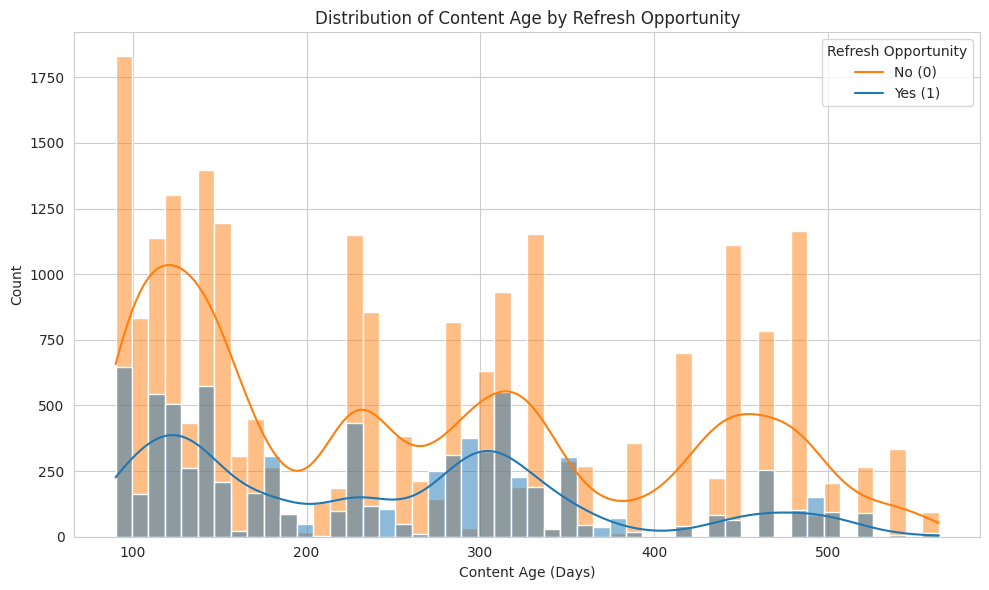

In [24]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# Plotting distribution of 'content_age_days' by 'measurable_opportunity'
plt.figure(figsize=(10, 6))
sns.histplot(data=df_features, x='content_age_days', hue='measurable_opportunity',
             kde=True, common_norm=False, bins=50)
plt.title('Distribution of Content Age by Refresh Opportunity')
plt.xlabel('Content Age (Days)')
plt.ylabel('Count')
plt.legend(title='Refresh Opportunity', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.